# Sampling distribution of the variance estimator
We consider a Gaussian random variable with mean $\mu= 5$ and standard deviation $\sigma=2$. We want to comepare the variance estimators
$$S^2_1 = \sum_{i=1}^n \frac{(X_i-\overline{X})^2}{n-1}$$
$$S^2_2 = \sum_{i=1}^n \frac{(X_i-\overline{X})^2}{n}$$  
for n=10 and n=100.



In [1]:
import numpy as np
n = 10
mu = 5
sigma = 2
rep = 10000

In [2]:
xrep = np.random.normal(loc=mu, scale=sigma, size=(rep,n))
xrep

array([[ 6.77999802,  4.60182747,  6.10532041, ...,  3.54472754,
         8.47669324,  4.9023337 ],
       [ 6.16964824,  4.36832517,  4.69099694, ...,  7.49316299,
         5.11627629,  7.57937524],
       [ 6.37530876,  6.17652875,  5.88049435, ...,  4.17697886,
         8.64386953,  6.24379144],
       ...,
       [ 5.53012688,  3.59932407,  2.5613442 , ...,  4.37246262,
         4.73438005,  9.12176303],
       [ 6.76089577,  2.64763203,  3.63001821, ...,  3.66694996,
         6.38975672,  2.37289184],
       [-1.55008068,  7.41213078,  2.48103057, ...,  3.54295335,
         3.61110582,  5.35577907]])

In [3]:
def S2_1(x):
  return ((x-x.mean())**2).sum()/(n-1)

def S2_2(x):
  return ((x-x.mean())**2).sum()/n

In [4]:
s2_1_rep = np.array([S2_1(x) for x in xrep])
s2_2_rep = np.array([S2_2(x) for x in xrep])

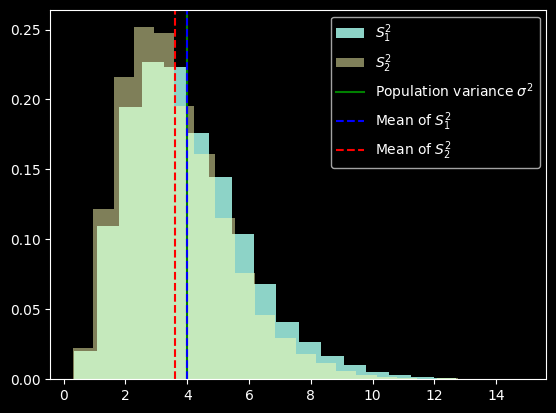

In [5]:
import matplotlib.pyplot as plt
plt.hist(s2_1_rep, 20, density=True, label = "$S^2_1$")
plt.hist(s2_2_rep, 20, density=True, alpha=0.5, label = "$S^2_2$")
plt.axvline(sigma**2, color='green', label="Population variance $\sigma^2$")
plt.axvline(s2_1_rep.mean(), color='blue', linestyle='--', label="Mean of $S^2_1$")
plt.axvline(s2_2_rep.mean(), color='red', linestyle='--', label="Mean of $S^2_2$")
plt.legend()

In [11]:
print("E[S^2_1] ≈ ", s2_1_rep.mean())
print("E[S^2_2] ≈ ", s2_2_rep.mean())
print("")
print("bias[S^2_1] ≈ ", s2_1_rep.mean()-sigma**2)
print("bias[S^2_2] ≈ ", s2_2_rep.mean()-sigma**2)


E[S^2_1] ≈  3.992542501181284
E[S^2_2] ≈  3.5932882510631554

bias[S^2_1] ≈  -0.007457498818716157
bias[S^2_2] ≈  -0.4067117489368446


The approximated expectation of $S^2_1$ is closer to the actual variance $\sigma^2 = 4$ than the approximated expectation of $S^2_2$.
You can re-run the code several time and check whether we were just lucky or this remains (almost) always true.  

One can prove that the bias of $S^2_2$ is equal to $-\frac{1}{n}\sigma^2$

In [7]:
print("bias[S^2_2] = ", -1/n*sigma**2)

bias[S^2_2] =  -0.4


In [8]:
print("SE[S^2_1] ≈ ", s2_1_rep.std(ddof = 1))
print("SE[S^2_2] ≈ ", s2_2_rep.std(ddof = 1))

SE[S^2_1] ≈  1.8942635604780356
SE[S^2_2] ≈  1.7048372044302318


The second estimator has a smaller standard error.

Consider now the estimators $S_1$ and $S_2$ of the standard deviation obtained taking the square root of $S^2_1$ and $S^2_2$, respectively.

Are they unbiased?

In [9]:
s_1_rep = np.sqrt(s2_1_rep)
s_2_rep = np.sqrt(s2_2_rep)

print("bias[S_1] ≈ ", s_1_rep.mean()- sigma)
print("bias[S_2] ≈ ", s_2_rep.mean()- sigma)

bias[S_1] ≈  -0.057034965452672726
bias[S_2] ≈  -0.15674152302881095


What changes if we increase n?